# 1. Instalación de librerías y configuración inicial

In [8]:
import glob
import logging
import os
import random
import shutil
import sys
import tarfile
import yaml

from collections import Counter, defaultdict
import cv2
import h5py
from huggingface_hub import hf_hub_download
from IPython import display
import json
import matplotlib.pyplot as plt
import numpy as np
import optuna
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances,
)
import pandas as pd
from PIL import Image
import scipy.io
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import torch
from torchvision.datasets import ImageFolder
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.utils import make_grid
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm, trange

In [9]:
def set_global_seed(seed: int = 24):
    """
    Fija todas las semillas necesarias para asegurar reproducibilidad
    en experimentos.
    """
    # Python y entorno
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)

    # NumPy
    np.random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # CuDNN (para asegurar resultados deterministas en GPU)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    print(f"Semillas fijadas en {seed}")

In [10]:
seed = 24
set_global_seed(seed)

Semillas fijadas en 24


In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("GPU disponible:", torch.cuda.is_available())
print("Nombre de la GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "Ninguna")

GPU disponible: True
Nombre de la GPU: NVIDIA GeForce RTX 5060 Ti


# 2. Carga de _dataset_ propio para _fine-tuning_

In [12]:
current_workspace = os.getcwd()
DATA_ROOT_CLASSIFICATION = os.path.abspath(os.path.join(current_workspace,
                                                     "..", "data",
                                                     "data_modelo_clasificación"))
TARGET_DIR = os.path.join(DATA_ROOT_CLASSIFICATION, "digits_yolo")
EXTRACTED_DATA_DIR = os.path.join(TARGET_DIR, "data")

os.makedirs(TARGET_DIR, exist_ok=True)
os.makedirs(EXTRACTED_DATA_DIR, exist_ok=True)

# Descarga de los archivos desde el dataset
repo_id = "U20212419/digits"

# Descargar data.tar
data_tar_path = hf_hub_download(repo_id=repo_id,
                                filename="data.tar",
                                repo_type="dataset")

# Descargar train.txt
train_txt_path = hf_hub_download(repo_id=repo_id,
                                 filename="train.txt",
                                 repo_type="dataset")

# Descargar data.yaml
data_yaml_path = hf_hub_download(repo_id=repo_id,
                                 filename="data.yaml",
                                 repo_type="dataset")

print("Archivos descargados exitosamente.")

# Extraer data.tar
print("\nExtrayendo data.tar en '{TARGET_DIR}'...")
with tarfile.open(data_tar_path, "r") as tar_ref:
    tar_ref.extractall(TARGET_DIR, filter="data")

print("Subcarpetas encontradas:", os.listdir(EXTRACTED_DATA_DIR))

# Cargar rutas de imágenes desde train.txt
with open(train_txt_path, "r") as f:
    image_paths = [line.strip() for line in f.readlines()]

print(f"Total de imágenes en train.txt: {len(image_paths)}")

# Cargar data.yaml
with open(data_yaml_path, "r") as f:
    data_yaml = yaml.safe_load(f)
data_yaml["path"] = EXTRACTED_DATA_DIR
data_yaml["train"] = "images/train"
data_yaml["val"] = "images/val"
data_yaml["test"] = "images/test"

print("\ndata.yaml cargado:")
print("path:", data_yaml["path"])
print("train:", data_yaml["train"])
print("val:", data_yaml["val"])
print("test:", data_yaml["test"])
print("classes:", data_yaml["names"])

# Guardar el YAML en la carpeta data
yaml_save_path = os.path.join(EXTRACTED_DATA_DIR, 'data.yaml')
with open(yaml_save_path, 'w') as f:
    yaml.dump(data_yaml, f, sort_keys=False)

# Verificar existencia de archivos
missing = []
for p in image_paths:
    # Limpiar el prefijo de train.txt para obtener la ruta relativa correcta
    clean_p = p.replace('./data/', '').replace('data/', '')
    full_path = os.path.join(EXTRACTED_DATA_DIR, clean_p)

    if not os.path.exists(full_path):
        missing.append(full_path)

if missing:
    print(f"{len(missing)} archivos no encontrados.")
else:
    print("Todas las imágenes existen.")

Archivos descargados exitosamente.

Extrayendo data.tar en '{TARGET_DIR}'...
Subcarpetas encontradas: ['data.yaml', 'images', 'images_crops', 'labels', 'labels_crops', 'labels_polygons']
Total de imágenes en train.txt: 1110

data.yaml cargado:
path: c:\Users\Flavio\Desktop\tesis_notebooks\data\data_modelo_reconocimiento\digits_yolo\data
train: images/train
val: images/val
test: images/test
classes: {0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9', 10: '.'}
Todas las imágenes existen.


In [ ]:
# Estructura de carpetas
def ensure_dir(path):
    if not os.path.exists(path):
        os.makedirs(path)

root_cropped = "data_cropped"
train_out = os.path.join(root_cropped, "train")
val_out = os.path.join(root_cropped, "val")
test_out = os.path.join(root_cropped, "test")
for i in range(num_classes):
    ensure_dir(os.path.join(train_out, str(i)))
    ensure_dir(os.path.join(val_out, str(i)))
    ensure_dir(os.path.join(test_out, str(i)))

Se recortan los _bounding boxes_ de las imágenes, utilizando las coordenadas normalizadas que provienen de las etiquetas del _dataset_, para obtener los caracteres individuales.

In [ ]:
def crop_bounding_box(image, points):
    """Recorta una caja rectangular dada por 4 puntos (x,y)."""
    h, w = image.shape[:2]
    pts = np.array(points, dtype=np.float32).reshape(4, 2)

    # Convertir coordenadas normalizadas a píxeles reales
    pts[:, 0] = pts[:, 0] * w
    pts[:, 1] = pts[:, 1] * h

    x_min = int(np.min(pts[:, 0]))
    x_max = int(np.max(pts[:, 0]))
    y_min = int(np.min(pts[:, 1]))
    y_max = int(np.max(pts[:, 1]))

    # Verificar límites válidos
    x_min = max(0, x_min)
    y_min = max(0, y_min)
    x_max = min(w, x_max)
    y_max = min(h, y_max)

    # Recorte
    cropped = image[y_min:y_max, x_min:x_max]

    # Evitar recortes vacíos
    if cropped.shape[0] < 2 or cropped.shape[1] < 2:
        return None

    # Redimensionar a 224x224
    cropped = cv2.resize(cropped, (224, 224))
    return cropped

In [ ]:
# Recortar todas las imágenes
label_dirs = glob.glob("data/labels/**/*.*", recursive=True)
print(f"Archivos de labels encontrados: {len(label_dirs)}")

for label_path in tqdm(label_dirs, desc="Procesando labels"):
    img_path = label_path.replace("labels",
                                  "images").rsplit(".", 1)[0] + ".jpg"
    if not os.path.exists(img_path):
        continue
    img = cv2.imread(img_path)
    if img is None:
        continue

    # Determinar el subconjunto
    subset = ("train" if "train/" in label_path
              else "val" if "val/" in label_path
              else "test")

    with open(label_path, "r") as f:
        for i, line in enumerate(f):
            parts = line.strip().split()
            if len(parts) != 9:
                continue
            cls = int(parts[0])
            coords = list(map(float, parts[1:]))
            cropped = crop_bounding_box(img, coords)

            if cropped is not None:
                crop_name = (f"{os.path.basename(img_path).split('.')[0]}"
                             f"_{i}.jpg")
                out_path = os.path.join(root_cropped, subset,
                                        str(cls), crop_name)
                cv2.imwrite(out_path, cropped)

print("\nRecortes almacenados en:", root_cropped)

Archivos de labels encontrados: 375


Procesando labels: 100%|██████████| 375/375 [00:08<00:00, 42.85it/s]


Recortes almacenados en: data_cropped


Se realiza el _split_ del conjunto de datos en subconjuntos de entrenamiento, validación y prueba. Se asegura todas las imágenes correspondientes a cada video original se encuentren en el mismo subconjunto, para evitar la fuga de datos, pues los fotogramas de un mismo video suelen tener características muy similares (misma escritura y condiciones de grabación).

In [ ]:
def split_train_val(base_dir="data_cropped/train",
                    val_ratio=0.15, test_ratio=0.15, seed=42):
    """
    Divide los crops de 'base_dir' (que contiene todas las clases)
    en nuevos directorios 'val' y 'test', asegurando que todos
    los crops de un mismo video permanezcan en el mismo split.
    """
    root_dir = os.path.dirname(base_dir)
    val_root = os.path.join(root_dir, "val")
    test_root = os.path.join(root_dir, "test")

    os.makedirs(val_root, exist_ok=True)
    os.makedirs(test_root, exist_ok=True)

    # Agrupar los crops por video_key
    video_groups = defaultdict(list)

    # Buscar todos los .jpg en todas las subcarpetas de clases
    all_crops = glob.glob(os.path.join(base_dir, "**", "*.jpg"),
                          recursive=True)
    if not all_crops:
        print(f"Error: No se encontraron crops en {base_dir}")
        return

    for crop_path in all_crops:
        crop_name = os.path.basename(crop_path)
        try:
            # Formato "video_ABC_...": la llave es "video_ABC"
            key_parts = crop_name.split('_')
            video_key = f"{key_parts[0]}_{key_parts[1]}"
            video_groups[video_key].append(crop_path)
        except IndexError:
            print(f"Advertencia: {crop_name} no tiene "
                  f"el formato de video esperado.")

    print(f"Encontrados {len(all_crops)} crops de "
          f"{len(video_groups)} videos únicos.")

    # Dividir los 'video_keys'
    video_keys = list(video_groups.keys())
    random.shuffle(video_keys)

    n_videos = len(video_keys)
    n_val = int(n_videos * val_ratio)
    n_test = int(n_videos * test_ratio)
    # n_train es el resto

    # (n_val) y (n_val + n_test) son los puntos de corte
    val_keys, test_keys, train_keys = np.split(
        video_keys,
        [n_val, n_val + n_test]
    )

    print(f"División de videos: {len(train_keys)} train, "
          f"{len(val_keys)} val, {len(test_keys)} test.")

    # Función auxiliar para mover archivos
    def move_video_files(keys_list, dest_root):
        """Mueve todos los crops de una lista de keys al destino."""
        moved_count = 0
        for key in tqdm(keys_list,
                        desc=f"Moviendo a {os.path.basename(dest_root)}"):
            for src_path in video_groups[key]:
                try:
                    # Obtener la clase del nombre de la carpeta
                    class_id = os.path.basename(os.path.dirname(src_path))

                    # Crear la carpeta de destino de la clase
                    dest_cls_dir = os.path.join(dest_root, class_id)
                    os.makedirs(dest_cls_dir, exist_ok=True)

                    # Mover el archivo
                    dest_path = os.path.join(dest_cls_dir,
                                             os.path.basename(src_path))
                    shutil.move(src_path, dest_path)
                    moved_count += 1
                except Exception as e:
                    print(f"Error moviendo {src_path}: {e}")
        return moved_count

    # Ejecutar el movimiento
    val_moved = move_video_files(val_keys, val_root)
    test_moved = move_video_files(test_keys, test_root)

    # Los archivos de train son los que quedan en base_dir
    train_final = len(all_crops) - val_moved - test_moved

    print("\n--- Split de Crops Completado ---")
    print(f"Crops de Train: {train_final}")
    print(f"Crops de Val: {val_moved}")
    print(f"Crops de Test: {test_moved}")

# Ejecutar el split
split_train_val("data_cropped/train",
                val_ratio=0.15,
                test_ratio=0.15,
                seed=seed)

Encontrados 6205 crops de 7 videos únicos.
División de videos: 5 train, 1 val, 1 test.


Moviendo a test: 100%|██████████| 1/1 [00:00<00:00, 56.47it/s]


--- Split de Crops Completado ---
Crops de Train: 4306
Crops de Val: 1599
Crops de Test: 300


Se crean los DataLoader para que el modelo pueda utilizar los subconjuntos. Se aplicaron transformaciones de _data augmentation_ al subconjunto de entrenamiento, se escalaron las imágenes de todos los subconjuntos a 224x224 (tamaño de entrada por defecto de ResNet), se convirtieron las imágenes a tensores y se normalizaron en función de la media y desviación estándar del subconjunto de entrenamiento.

In [ ]:
def compute_mean_std(dataset_path):
    """Hallar la media y desviación estándar de un conjunto de datos."""
    # Transformación mínima solo para leer imágenes
    tmp_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])

    # Dataset temporal
    dataset_tmp = ImageFolder(root=dataset_path,
                              transform=tmp_transform)

    # DataLoader
    generator = torch.Generator().manual_seed(seed)
    loader = DataLoader(dataset_tmp, batch_size=64,
                        shuffle=False, num_workers=2,
                        generator=generator)

    # Cálculo de la media y desviación estándar
    mean = torch.zeros(3, dtype=torch.float64)
    std = torch.zeros(3, dtype=torch.float64)
    total = 0
    with torch.no_grad():
        for imgs, _ in loader:
            batch_samples = imgs.size(0)
            imgs = imgs.view(batch_samples, imgs.size(1), -1)
            mean += imgs.mean(2).sum(0).double()
            std += imgs.std(2).sum(0).double()
            total += batch_samples
    mean /= total
    std /= total
    return mean.tolist(), std.tolist()

mean, std = compute_mean_std("data_cropped/train")
print(f"Mean: {mean}, Std: {std}")

Mean: [0.7138324946621879, 0.6752742936984362, 0.6944984441793525], Std: [0.06064024192479617, 0.08277346212477447, 0.07542827455486965]


In [ ]:
# Transformaciones
train_transform = transforms.Compose([
    transforms.RandomAffine(
        # Rotación
        degrees=5,
        # Traslación en los ejes x, y
        translate=(0.05, 0.05),
        # Inclinación
        shear=3,
        # Rellena con blanco
        fill=255
    ),
    # Zoom ligero
    transforms.RandomResizedCrop(224, scale=(0.85, 1.05)),
    # Cambio de brillo, contraste, saturación y tono
    transforms.ColorJitter(brightness=0.5, contrast=0.2,
                           saturation=0.3, hue=0.4),
    # Simular desenfoque
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 5.0))
    ], p=0.5),  # 50% de probabilidad de aplicar esto
    # Simular pixelación (baja la escala y la vuelve a subir)
    transforms.RandomApply([
        transforms.Resize((64, 64)),
        transforms.Resize((224, 224))
    ], p=0.5),  # 50% de probabilidad de aplicar esto
    # Convertir a tensor
    transforms.ToTensor(),
    # Borrar parte de la imagen aleatoriamente
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.2), ratio=(0.3, 3.3)),
    # Normalizar
    transforms.Normalize(mean=mean, std=std)
])
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

In [ ]:
# DataLoaders
generator = torch.Generator().manual_seed(seed)
train_dataset = ImageFolder(root="data_cropped/train",
                            transform=train_transform)
val_dataset = ImageFolder(root="data_cropped/val",
                          transform=val_transform)
test_dataset = ImageFolder(root="data_cropped/test",
                           transform=test_transform)

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=2,
                          generator=generator)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE,
                        shuffle=False, num_workers=2,
                        generator=generator)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=2,
                         generator=generator)

print(f"Clases detectadas: {train_dataset.classes} "
      f"('10' es el separador decimal)")
print(f"Total train: {len(train_dataset)}, "
      f"val: {len(val_dataset)}, test: {len(test_dataset)}")

Clases detectadas: ['0', '1', '10', '2', '3', '4', '5', '6', '7', '8', '9'] ('10' es el separador decimal)
Total train: 4306, val: 1599, test: 300


Mostrando 8 imágenes transformadas del set de 'train'...
Clases: ['5', '10', '5', '2', '2', '0', '5', '0']


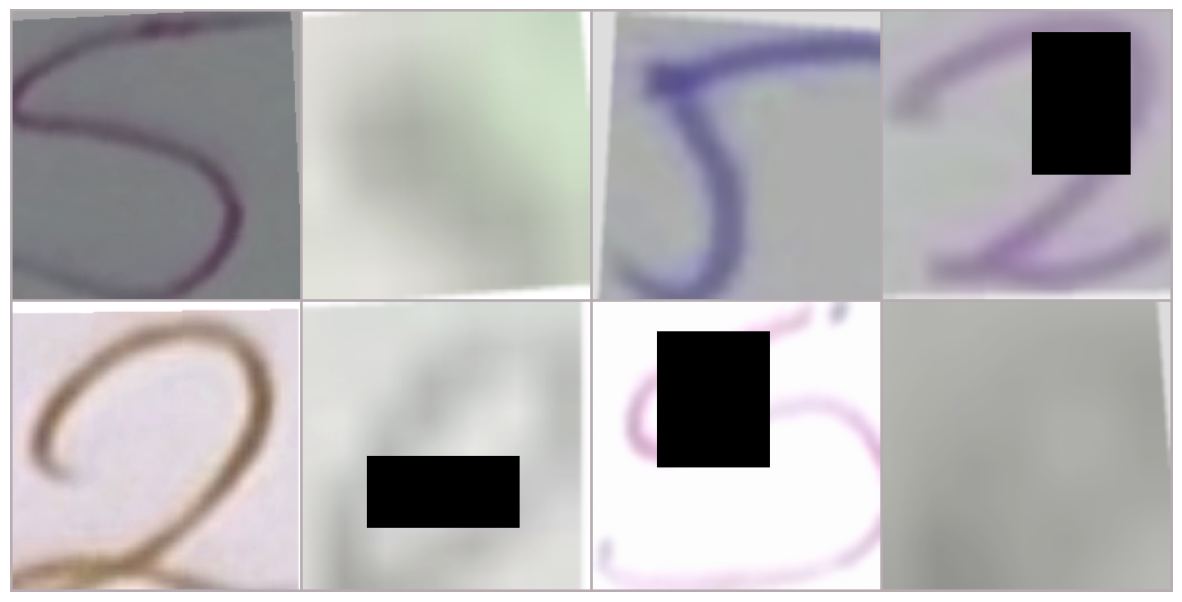

In [ ]:
# Revertir la normalización
mean_tensor = torch.tensor(mean)
std_tensor = torch.tensor(std)

def unnormalize(img):
    """Revierte la normalización de ToTensor para visualización."""
    # Clonar para evitar modificar el tensor original
    img = img.clone()

    # Reorganizar las dimensiones de (C, H, W) a (H, W, C) para plt
    img = img.permute(1, 2, 0)

    # Aplicar la fórmula inversa: img = (img * std) + mean
    img = img * std_tensor + mean_tensor

    # Asegurar que los valores estén entre 0 y 1
    img = torch.clamp(img, 0, 1)
    return img

# Tomar un batch del train_loader
try:
    inputs, classes = next(iter(train_loader))
except Exception as e:
    print(f"Error al cargar el batch: {e}")
    print("Asegúrate de que 'train_loader' esté definido.")

# Crear una grilla y mostrar las imágenes
# (las primeras 8 imágenes del batch)
grid = make_grid(inputs[:8], nrow=4)
img_to_show = unnormalize(grid)

print(f"Mostrando 8 imágenes transformadas del set de 'train'...")
print(f"Clases: {[train_dataset.classes[c] for c in classes[:8]]}")

plt.figure(figsize=(15, 8))
plt.imshow(img_to_show)
plt.axis('off')
plt.show()

#3. Optimización de hiperparámetros

Se realiza un estudio de optimización de hiperparámetros utilizando Optuna, buscando maximizar la exactitud de validación. Cada intento dura 20 épocas, con _early stopping_ con paciencia de 7 épocas y _learning rate scheduler_ en función de la pérdida de validación con paciencia de 3 épocas, para evitar el sobreajuste y asegurar una convergencia correcta.

In [ ]:
def objective(trial):
    # Hiperparámetros
    lr = trial.suggest_float("lr", 1e-6, 1e-3, log=True)
    optimizer_name = "AdamW"
    dropout = trial.suggest_float("dropout", 0.0, 0.6)
    weight_decay = trial.suggest_float("weight_decay",
                                       1e-6, 1e-1, log=True)
    batch_size = trial.suggest_categorical("batch_size", [8, 16, 32, 64])
    unfreeze_blocks = trial.suggest_int("unfreeze_blocks", 0, 4)

    # Imprimir hiperparámetros al inicio del trial
    logging.info(f"\nTrial {trial.number} - Hiperparámetros:")
    logging.info(f"  lr: {lr}")
    logging.info(f"  optimizer_name: {optimizer_name}")
    logging.info(f"  dropout: {dropout}")
    logging.info(f"  weight_decay: {weight_decay}")
    logging.info(f"  batch_size: {batch_size}")
    logging.info(f"  unfreeze_blocks: {unfreeze_blocks}")

    # DataLoaders
    generator = torch.Generator().manual_seed(seed)
    train_loader = DataLoader(train_dataset, batch_size=batch_size,
                          shuffle=True, num_workers=2,
                          generator=generator)
    val_loader = DataLoader(val_dataset, batch_size=batch_size,
                            shuffle=False, num_workers=2,
                            generator=generator)

    # Modelo
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    num_features = model.fc.in_features

    # Congelar toda la red
    for param in model.parameters():
        param.requires_grad = False

    # Aplicar dropout y nueva capa final
    model.fc = nn.Sequential(
        nn.Dropout(p=dropout),
        nn.Linear(num_features, 11)
    )

    # Descongelar la cabeza
    for param in model.fc.parameters():
        param.requires_grad = True

    # Descongelar N bloques desde el final
    if unfreeze_blocks > 0:
        blocks = [model.layer4, model.layer3, model.layer2, model.layer1]
        for i in range(unfreeze_blocks):
            for param in blocks[i].parameters():
                param.requires_grad = True

    model = model.to(device)

    # Criterio y optimizador
    criterion = nn.CrossEntropyLoss()
    trainable_params = filter(lambda p: p.requires_grad,
                              model.parameters())
    optimizer = optim.AdamW(trainable_params, lr=lr,
                            weight_decay=weight_decay)

    # Scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer,
                                                     mode='min',
                                                     factor=0.5,
                                                     patience=3)

    # Bucle de entrenamiento y validación
    n_epochs = 20
    best_val_acc = 0.0
    patience_counter = 0
    PATIENCE_LIMIT = 7
    try:
        for epoch in trange(n_epochs, desc=f"Trial {trial.number}",
                            leave=True):
            # Entrenamiento
            model.train()
            train_correct, total_train_loss = 0, 0.0
            for inputs, labels in train_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                total_train_loss += loss.item() * inputs.size(0)
                train_correct += (outputs.argmax(1) ==
                                  labels).sum().item()
            train_acc = train_correct / len(train_loader.dataset)
            train_loss = total_train_loss / len(train_loader.dataset)

            # Validación
            model.eval()
            val_correct, total_val_loss = 0, 0.0
            with torch.no_grad():
                for inputs, labels in val_loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    total_val_loss += loss.item() * inputs.size(0)
                    val_correct += (outputs.argmax(1) ==
                                    labels).sum().item()
            val_loss = total_val_loss / len(val_loader.dataset)
            val_acc = val_correct / len(val_loader.dataset)

            # Scheduler step
            scheduler.step(val_loss)

            # Lógica de early stopping
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                patience_counter = 0
            else:
                patience_counter += 1

            logging.info(f"[Trial {trial.number}] "
                         f"Epoch {epoch+1}/{n_epochs} | "
                         f"Train Loss: {train_loss:.4f} | "
                         f"Train Acc: {train_acc:.4f} | "
                         f"Val Loss: {val_loss:.4f} | "
                         f"Val Acc: {val_acc:.4f}")

            trial.report(val_acc, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

            if patience_counter >= PATIENCE_LIMIT:
                logging.info(f"Early stopping en época {epoch+1}.")
                break

        return best_val_acc

    except optuna.TrialPruned:
        logging.info(f"Trial {trial.number} podado por pruner.")
        raise
    except RuntimeError as e:
        if 'out of memory' in str(e):
            logging.info(f"Trial {trial.number} "
                         f"podado por falta de memoria.")
            raise optuna.exceptions.TrialPruned()
        else:
            raise e

In [ ]:
# Ruta en Drive donde se guardará el archivo SQLite
drive_db_path = ("/content/drive/MyDrive/digits_resnet"
                 "/digits_resnet_optuna.db")

# Ruta local temporal en Colab
local_db_path = "/content/digits_resnet_optuna.db"

# Si ya existe en Drive, copiarlo al entorno de Colab
if os.path.exists(drive_db_path):
    shutil.copy(drive_db_path, local_db_path)
    print("Archivo SQLite copiado desde Drive")
else:
    print("No se encontró archivo en Drive, se creará uno nuevo")

# Callback para guardar automáticamente en Drive
class BackupCallback:
    """
    Callback de Optuna en formato de clase para guardar
    la base de datos en Drive.

    Esta clase se configura con las rutas de origen y
    destino al ser creada, luego realiza la copia en cada llamada.
    """
    def __init__(self, local_path: str, drive_path: str):
        """
        Constructor para configurar la callback.

        Args:
            local_path (str): La ruta del archivo .db
                              en el entorno de Colab.
            drive_path (str): La ruta de destino para la
                              copia en Google Drive.
        """
        self.local_db_path = local_path
        self.drive_db_path = drive_path

    def __call__(self, study: optuna.study.Study,
                 trial: optuna.trial.FrozenTrial):
        """
        El método que hace que el objeto sea 'callable'
        y sea ejecutado por Optuna.
        """
        try:
            shutil.copy(self.local_db_path, self.drive_db_path)
            logging.info(f"Backup del Trial {trial.number} "
                         f"guardado exitosamente en Drive.")
        except Exception as e:
            logging.error(f"Error al hacer backup del "
                          f"Trial {trial.number}: {e}")
backup_to_drive = BackupCallback(local_path=local_db_path,
                                 drive_path=drive_db_path)

Archivo SQLite copiado desde Drive


In [ ]:
# Ruta en Drive donde se guardará la salida del estudio
log_path = ("/content/drive/MyDrive/digits_resnet/"
            "digits_resnet_optuna.log")

# Crear logger raíz
logger = logging.getLogger()
logger.setLevel(logging.INFO)

# Limpiar cualquier handler previo
if logger.hasHandlers():
    logger.handlers.clear()

# Handler para consola (stdout)
console_handler = logging.StreamHandler(sys.stdout)
console_handler.setLevel(logging.INFO)
console_formatter = logging.Formatter(f"%(asctime)s [%(levelname)s] "
                                      f"- %(message)s")
console_handler.setFormatter(console_formatter)

# Handler para archivo
file_handler = logging.FileHandler(log_path, mode='a')
file_handler.setLevel(logging.INFO)
file_handler.setFormatter(console_formatter)

# Agregar handlers al logger
logger.addHandler(console_handler)
logger.addHandler(file_handler)

# Callback de Optuna para forzar flush del log después de cada trial
class FlushLogCallback:
    """Callback de Optuna para forzar la escritura del log en disco."""
    def __call__(self, study: optuna.study.Study,
                 trial: optuna.trial.FrozenTrial):
        for handler in logger.handlers:
            if isinstance(handler, logging.FileHandler):
                handler.flush()
flush_log_callback = FlushLogCallback()

In [ ]:
# Cargar el estudio solo para contar los trials existentes
try:
    n_completed_trials = len(
        optuna.load_study(
            study_name="digits_resnet_tuning",
            storage=f"sqlite:///{local_db_path}"
            ).trials
        )
except KeyError:
    n_completed_trials = 0

# Sampler con semilla que depende del número de trials existentes
# Esto asegura una secuencia de sugerencias continua y reproducible
sampler = optuna.samplers.TPESampler(seed=seed + n_completed_trials)

# Pruner para cortar trials malos
pruner = optuna.pruners.MedianPruner(n_startup_trials=3, n_warmup_steps=2)

# Crear el estudio
study = optuna.create_study(
    study_name="digits_resnet_tuning",
    direction="maximize",
    sampler=sampler,
    pruner=pruner,
    storage=f"sqlite:///{local_db_path}",  # Archivo local de persistencia
    load_if_exists=True
)

logging.info(f"Dirección: {study.direction.name}")

logging.info(f"Reanudando estudio. "
             f"Se han completado {n_completed_trials} trials.")
logging.info(f"El sampler se ha inicializado con la semilla "
             f"{seed + n_completed_trials}")

optuna.logging.set_verbosity(optuna.logging.WARNING)

[I 2025-11-01 03:39:49,936] Using an existing study with name 'digits_resnet_tuning' instead of creating a new one.


2025-11-01 03:39:49,942 [INFO] - Dirección: MAXIMIZE
2025-11-01 03:39:50,685 [INFO] - Reanudando estudio. Se han completado 20 trials.
2025-11-01 03:39:50,686 [INFO] - El sampler se ha inicializado con la semilla 44


In [ ]:
# Ejecutar la optimización
try:
    study.optimize(objective,
                  n_trials=20,
                  timeout=None,
                  show_progress_bar=True,
                  callbacks=[backup_to_drive, flush_log_callback])
finally:
    # Mostrar mejores resultados
    try:
        best_trial = study.best_trial
        logging.info(f'\n=== MEJORES RESULTADOS ===')
        logging.info(f"Mejor trial: Trial {best_trial.number}")
        logging.info(f"Accuracy: {best_trial.value:.4f}")
        logging.info("Hiperparámetros:")
        for k, v in best_trial.params.items():
            logging.info(f"  {k}: {v}")
    except ValueError:
        logging.warning(f"El estudio finalizó sin trials completados "
                        f"exitosamente. No se puede mostrar un "
                        f"'mejor trial'.")

    logging.shutdown()
    print("Proceso finalizado. Log guardado y cerrado correctamente.")

[I 2025-10-31 20:33:39,960] A new study created in RDB with name: digits_resnet_tuning


2025-10-31 20:33:39,963 [INFO] - Dirección: MAXIMIZE
2025-10-31 20:33:39,966 [INFO] - Reanudando estudio. Se han completado 0 trials.
2025-10-31 20:33:39,967 [INFO] - El sampler se ha inicializado con la semilla 24


  0%|          | 0/20 [00:00<?, ?it/s]

2025-10-31 20:33:40,064 [INFO] - 
Trial 0 - Hiperparámetros:
2025-10-31 20:33:40,065 [INFO] -   lr: 0.0007586682511093436
2025-10-31 20:33:40,067 [INFO] -   optimizer_name: AdamW
2025-10-31 20:33:40,069 [INFO] -   dropout: 0.41970722996974563
2025-10-31 20:33:40,070 [INFO] -   weight_decay: 0.09984733164388904
2025-10-31 20:33:40,071 [INFO] -   batch_size: 64
2025-10-31 20:33:40,072 [INFO] -   unfreeze_blocks: 1
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth



  0%|          | 0.00/44.7M [00:00<?, ?B/s]
 44%|████▎     | 19.5M/44.7M [00:00<00:00, 203MB/s]
100%|██████████| 44.7M/44.7M [00:00<00:00, 209MB/s]

Trial 0:   0%|          | 0/20 [00:00<?, ?it/s]

...


Trial 19:  40%|████      | 8/20 [06:17<09:26, 47.18s/it]

2025-10-31 23:11:55,191 [INFO] - [Trial 19] Epoch 9/20 | Train Loss: 0.0586 | Train Acc: 0.9805 | Val Loss: 0.0249 | Val Acc: 0.9937
2025-10-31 23:11:55,216 [INFO] - Early stopping en época 9.


Trial 19:  40%|████      | 8/20 [07:04<10:36, 53.05s/it]

2025-10-31 23:11:55,254 [INFO] - Backup del Trial 19 guardado exitosamente en Drive.
2025-10-31 23:11:55,279 [INFO] - 
=== MEJORES RESULTADOS ===
2025-10-31 23:11:55,280 [INFO] - Mejor trial: Trial 13
2025-10-31 23:11:55,281 [INFO] - Accuracy: 0.9981
2025-10-31 23:11:55,282 [INFO] - Hiperparámetros:
2025-10-31 23:11:55,283 [INFO] -   lr: 0.00018548625246402414
2025-10-31 23:11:55,283 [INFO] -   dropout: 0.10476809806637458
2025-10-31 23:11:55,285 [INFO] -   weight_decay: 0.0044210379158176145
2025-10-31 23:11:55,286 [INFO] -   batch_size: 8
2025-10-31 23:11:55,286 [INFO] -   unfreeze_blocks: 4


Proceso finalizado. Log guardado y cerrado correctamente.


In [ ]:
# Visualización a lo largo del estudio
plot_optimization_history(study).show()
plot_param_importances(study).show()

In [ ]:
# Descargar gráficos de optuna
fig1 = plot_optimization_history(study)
fig1.write_image("/content/drive/MyDrive/digits_resnet"
                 "/plots/optuna_optimization_history.svg")
fig2 = plot_param_importances(study)
fig2.write_image("/content/drive/MyDrive/digits_resnet"
                 "/plots/optuna_param_importances.svg")

Todos los intentos, a excepción del Trial 1, lograron un valor alto de exactitud de validación mayor a 0.98 y el mejor resultado se logró en el Trial 13, con una exactitud de 0.9981.

El hiperparámetro que tuvo la mayor importancia durante el estudio de optimización fue el valor de la _learning rate_; este tuvo que ajustarse de tal modo que no se olviden los pesos prentrenados en ImageNet, pero que igualmente el modelo pueda aprender las características de la nueva tarea.

En cuanto a la regularización, el _weight decay_ y el _dropout_ tuvieron pesos similares y obtuvieron los siguientes lugares en importancia, así que se confió en estos para prevenir el sobreajuste. Además, el _batch size_ fue el más pequeño del espacio de búsqueda, introduciendo más ruido, lo que podría haber ayudado a generalizar mejor.

La cantidad de capas descongeladas fue el de menor importancia y el valor elegido fue 4 (todas las capas), posiblemente porque la tarea de clasificación de dígitos fue suficientemente diferente de ImageNet para el modelo.

Carpeta en Drive con la evidencia de ejecución (archivos con el sufijo "_optuna"): https://drive.google.com/drive/folders/1qWqMvnlDhRsd8EGHj9ZV219paN4WHNVG?usp=sharing

#4. _Fine-tuning_

Utilizando los hiperparámetros obtenidos, se realiza un _fine-tuning_ final con el fin de ver si se pueden mejorar los resultados. Este entrenamiento se realiza por 100 épocas, _early stopping_ con paciencia de 20 épocas y el _learning rate scheduler_ con paciencia de 5 épocas. El modo de entrenamiento es similar al de la función objetivo utilizada para la optimización de hiperparámetros.

In [ ]:
# Cargar el estudio final luego de la optimización de hiperparámetros
final_study = optuna.load_study(
    study_name="digits_resnet_tuning",
    sampler=sampler,
    pruner=pruner,
    storage=f"sqlite:///{local_db_path}",
)

best_params = final_study.best_trial.params
best_params

{'lr': 0.00018548625246402414,
 'dropout': 0.10476809806637458,
 'weight_decay': 0.0044210379158176145,
 'batch_size': 8,
 'unfreeze_blocks': 4}

In [ ]:
# Limpiar logger anterior
for handler in logging.root.handlers[:]:
    logging.root.removeHandler(handler)

# Ruta en Drive donde se guardará la salida del entrenamiento final
final_log_path = ("/content/drive/MyDrive/digits_resnet/"
                  "digits_resnet_final.log")

# Crear logger
logger_final = logging.getLogger("final_training")
logger_final.setLevel(logging.INFO)

# Limpiar cualquier handler previo
if logger_final.hasHandlers():
    logger_final.handlers.clear()

# Handler para consola (stdout)
console_handler = logging.StreamHandler(sys.stdout)
console_handler.setLevel(logging.INFO)
console_formatter = logging.Formatter(f"%(asctime)s [%(levelname)s] "
                                      f"- %(message)s")
console_handler.setFormatter(console_formatter)

# Handler para archivo
os.makedirs(os.path.dirname(final_log_path), exist_ok=True)
file_handler = logging.FileHandler(final_log_path, mode='a')
file_handler.setLevel(logging.INFO)
file_handler.setFormatter(console_formatter)

# Agregar handlers al logger
logger_final.addHandler(console_handler)
logger_final.addHandler(file_handler)

In [ ]:
# DataLoaders
generator = torch.Generator().manual_seed(seed)
train_loader = DataLoader(train_dataset,
                          batch_size=best_params.get("batch_size"),
                          shuffle=True, num_workers=2,
                          generator=generator)
val_loader = DataLoader(val_dataset,
                        batch_size=best_params.get("batch_size"),
                        shuffle=False, num_workers=2,
                        generator=generator)

In [ ]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
num_features = model.fc.in_features

# Congelar toda la red
for param in model.parameters():
    param.requires_grad = False

# Aplicar dropout y nueva capa final
model.fc = nn.Sequential(
    nn.Dropout(p=best_params.get("dropout")),
    nn.Linear(num_features, 11)
)

# Descongelar la cabeza
for param in model.fc.parameters():
    param.requires_grad = True

# Descongelar N bloques desde el final
if best_params.get("unfreeze_blocks") > 0:
    blocks = [model.layer4, model.layer3, model.layer2, model.layer1]
    for i in range(best_params.get("unfreeze_blocks")):
        for param in blocks[i].parameters():
            param.requires_grad = True

model = model.to(device)

In [ ]:
# Criterio y optimizador
criterion = nn.CrossEntropyLoss()
trainable_params = filter(lambda p: p.requires_grad,
                          model.parameters())
optimizer = optim.AdamW(trainable_params, lr=best_params.get("lr"),
                        weight_decay=best_params.get("weight_decay"))

In [ ]:
# Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer,
                                                 mode='min',
                                                 factor=0.5,
                                                 patience=5)

In [ ]:
# Entrenamiento y validación con early stopping
n_epochs = 100
patience = 20
epochs_no_improve = 0
best_val_loss = float('inf')
best_model_path = ("/content/drive/MyDrive/digits_resnet"
                   "/digits_resnet_best_checkpoint.pt")
resume_path = ("/content/drive/MyDrive/digits_resnet"
               "/digits_resnet_resume.pt")
metrics_path = ("/content/drive/MyDrive/digits_resnet"
                "/digits_resnet_metrics.csv")

# Si existe un checkpoint previo, reanudar desde ahí
start_epoch = 1
if os.path.exists(resume_path):
    checkpoint = torch.load(resume_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    best_val_loss = checkpoint["best_val_loss"]
    epochs_no_improve = checkpoint["epochs_no_improve"]
    start_epoch = checkpoint["epoch"] + 1
    logger_final.info(f"Reanudando entrenamiento desde "
                      f"la época {start_epoch}...")
else:
    logger_final.info("Entrenamiento nuevo iniciado.")

if os.path.exists(metrics_path):
    prev_df = pd.read_csv(metrics_path)
    train_losses = prev_df["train_loss"].tolist()
    val_losses = prev_df["val_loss"].tolist()
    train_accuracies = prev_df["train_acc"].tolist()
    val_accuracies = prev_df["val_acc"].tolist()
    logger_final.info(f"Métricas previas cargadas.")
else:
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

for epoch in trange(start_epoch, n_epochs + 1,
                    desc="Entrenando", position=0):
    # Entrenamiento
    model.train()
    train_correct, total_train_loss = 0, 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item() * inputs.size(0)
        train_correct += (outputs.argmax(1) ==
                          labels).sum().item()
    train_acc = train_correct / len(train_loader.dataset)
    train_loss = total_train_loss / len(train_loader.dataset)

    # Validación
    model.eval()
    val_correct, total_val_loss = 0, 0.0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_val_loss += loss.item() * inputs.size(0)
            val_correct += (outputs.argmax(1) ==
                            labels).sum().item()
    val_loss = total_val_loss / len(val_loader.dataset)
    val_acc = val_correct / len(val_loader.dataset)

    # Scheduler step
    scheduler.step(val_loss)

    # Guardar métricas
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    logger_final.info(f"Epoch {epoch}/{n_epochs} | "
                      f"Train Loss: {train_loss:.4f} | "
                      f"Train Acc: {train_acc:.4f} | "
                      f"Val Loss: {val_loss:.4f} | "
                      f"Val Acc: {val_acc:.4f}")

    # Guardar mejor modelo
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), best_model_path)
        logger_final.info("Nuevo mejor modelo guardado.")
    else:
        epochs_no_improve += 1
        logger_final.info(f"Sin mejora en "
                          f"{epochs_no_improve}/{patience} épocas.")

    # Guardar estado para reanudar si se corta
    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_val_loss": best_val_loss,
        "epochs_no_improve": epochs_no_improve
    }
    temp_path = resume_path + ".tmp"
    torch.save(checkpoint, temp_path)
    os.replace(temp_path, resume_path)
    logger_final.info(f"Estado de entrenamiento "
                      f"guardado en {resume_path}")

    # Guardar métricas en un DataFrame
    metrics_df = pd.DataFrame({
        "epoch": list(range(1, len(train_losses) + 1)),
        "train_loss": train_losses,
        "val_loss": val_losses,
        "train_acc": train_accuracies,
        "val_acc": val_accuracies
    })

    metrics_df.to_csv(metrics_path, index=False)
    logger_final.info(f"Métricas guardadas en {metrics_path}")

    if epochs_no_improve >= patience:
        logger_final.info("Early stopping activado.")
        break

logger_final.info("Entrenamiento finalizado.")
logging.shutdown()
print("Proceso finalizado. Log guardado y cerrado correctamente.")

2025-11-01 04:17:21,832 [INFO] - Entrenamiento nuevo iniciado.


Entrenando:   0%|          | 0/100 [00:00<?, ?it/s]

2025-11-01 04:18:06,669 [INFO] - Epoch 1/100 | Train Loss: 0.5438 | Train Acc: 0.8333 | Val Loss: 0.1330 | Val Acc: 0.9437
2025-11-01 04:18:06,803 [INFO] - Nuevo mejor modelo guardado.
2025-11-01 04:18:07,180 [INFO] - Estado de entrenamiento guardado en /content/drive/MyDrive/digits_resnet/digits_resnet_resume.pt
2025-11-01 04:18:07,189 [INFO] - Métricas guardadas en /content/drive/MyDrive/digits_resnet/digits_resnet_metrics.csv


Entrenando:   1%|          | 1/100 [00:45<1:14:50, 45.35s/it]

2025-11-01 04:18:53,751 [INFO] - Epoch 2/100 | Train Loss: 0.2122 | Train Acc: 0.9392 | Val Loss: 0.0565 | Val Acc: 0.9831
2025-11-01 04:18:53,878 [INFO] - Nuevo mejor modelo guardado.
2025-11-01 04:18:54,276 [INFO] - Estado de entrenamiento guardado en /content/drive/MyDrive/digits_resnet/digits_resnet_resume.pt
2025-11-01 04:18:54,297 [INFO] - Métricas guardadas en /content/drive/MyDrive/digits_resnet/digits_resnet_metrics.csv


...

Entrenando:  91%|█████████ | 91/100 [1:14:23<07:18, 48.71s/it]

2025-11-01 05:32:34,256 [INFO] - Epoch 92/100 | Train Loss: 0.0051 | Train Acc: 0.9981 | Val Loss: 0.0032 | Val Acc: 0.9987
2025-11-01 05:32:34,260 [INFO] - Sin mejora en 20/20 épocas.
2025-11-01 05:32:34,638 [INFO] - Estado de entrenamiento guardado en /content/drive/MyDrive/digits_resnet/digits_resnet_resume.pt
2025-11-01 05:32:34,649 [INFO] - Métricas guardadas en /content/drive/MyDrive/digits_resnet/digits_resnet_metrics.csv
2025-11-01 05:32:34,650 [INFO] - Early stopping activado.


Entrenando:  91%|█████████ | 91/100 [1:15:12<07:26, 49.59s/it]

2025-11-01 05:32:34,653 [INFO] - Entrenamiento finalizado.


Proceso finalizado. Log guardado y cerrado correctamente.


In [ ]:
metrics_path = ("/content/drive/MyDrive/digits_resnet"
                "/digits_resnet_metrics.csv")
df = pd.read_csv(metrics_path)

output_dir = "/content/drive/MyDrive/digits_resnet/plots"
os.makedirs(output_dir, exist_ok=True)

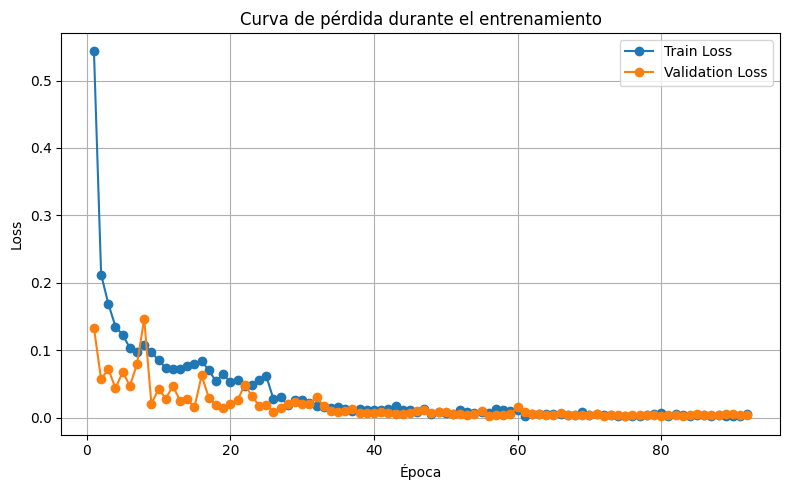

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(df["epoch"], df["train_loss"],
         label="Train Loss", marker='o')
plt.plot(df["epoch"], df["val_loss"],
         label="Validation Loss", marker='o')
plt.title("Curva de pérdida durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "loss_curve.svg"), format='svg')
plt.show()

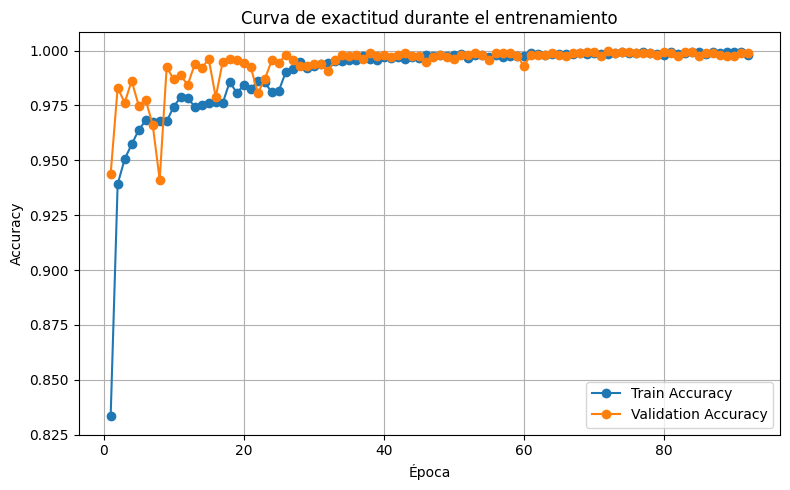

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(df["epoch"], df["train_acc"],
         label="Train Accuracy", marker='o')
plt.plot(df["epoch"], df["val_acc"],
         label="Validation Accuracy", marker='o')
plt.title("Curva de exactitud durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "accuracy_curve.svg"), format='svg')
plt.show()

No se aprecian indicios de sobreajuste. La convergencia de la pérdida de validación es un poco accidentada durante las primeras épocas, pero sigue disminuyendo a la par de la pérdida de entrenamiento. Se puede ver que el modelo converge alrededor de la época 40, logrando mejoras mínimas hasta que se activa el _early stopping_ en la época 91, habiendo obtenido finalmente los mejores resultados en la época 71.

Carpeta en Drive con la evidencia de ejecución: https://drive.google.com/drive/folders/1qWqMvnlDhRsd8EGHj9ZV219paN4WHNVG?usp=sharing

Además, los pesos del modelo final pueden ser descargados a través del siguiente enlace, desde el repositorio en Hugging Face: https://doi.org/10.57967/hf/6908

##Evaluación final

In [ ]:
# Cargar mejor modelo
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

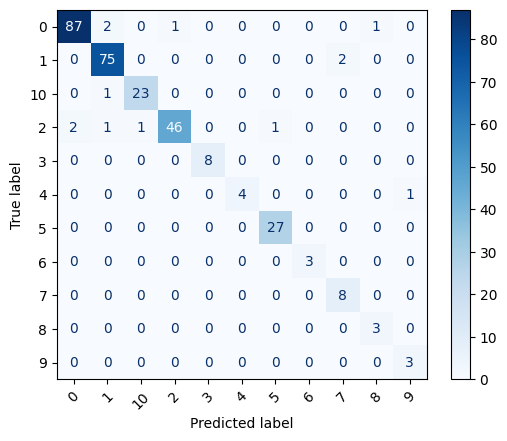


--- Reporte de Clasificación ---
              precision    recall  f1-score   support

           0     0.9775    0.9560    0.9667        91
           1     0.9494    0.9740    0.9615        77
          10     0.9583    0.9583    0.9583        24
           2     0.9787    0.9020    0.9388        51
           3     1.0000    1.0000    1.0000         8
           4     1.0000    0.8000    0.8889         5
           5     0.9643    1.0000    0.9818        27
           6     1.0000    1.0000    1.0000         3
           7     0.8000    1.0000    0.8889         8
           8     0.7500    1.0000    0.8571         3
           9     0.7500    1.0000    0.8571         3

    accuracy                         0.9567       300
   macro avg     0.9207    0.9628    0.9363       300
weighted avg     0.9597    0.9567    0.9570       300



In [ ]:
# Matriz de confusión de las predicciones sobre el conjunto de prueba
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        preds = model(imgs).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

class_names = test_dataset.classes

cm = confusion_matrix(all_labels, all_preds)
cm_display = ConfusionMatrixDisplay(cm,
                                    display_labels=class_names)
cm_display.plot(cmap="Blues", xticks_rotation=45)
cm_norm_path = os.path.join(output_dir,
                            "confusion_matrix_val.svg")
plt.savefig(cm_norm_path, format="svg")
plt.show()

print("\n--- Reporte de Clasificación ---")
report = classification_report(all_labels, all_preds,
                               target_names=class_names,
                               digits=4)
print(report)

Se logran excelentes resultados en el subconjunto de prueba. La exactitud obtenida es mayor al valor mínimo esperado (mayor a 0.95). Además, el F1-score asignando pesos a cada clase, lo cual es importante por el desbalance notorio, tiene un valor similar, así que se comprueba que la exactitud no está siendo inflada por el desbalance de clases.

En cuanto al F1-score macro, se logra un valor ligeramente menor, debido a una mayor cantidad de falsos positivos para algunas clases minoritarias (7, 8 y 9); aun así, las predicciones sobre otras clases minoritarias (3, 4 y 6) no mostraron falsos positivos. Entonces, el problema probablemente se da debido a la dificultad específica de esas clases. Es importante notar que, aunque la precisión de las clases 7, 8 y 9 fue el punto más débil, su _recall_ fue perfecto. Esto significa que el modelo nunca falló en encontrar un 7, 8 o 9 real; su único error fue que, ocasionalmente, confundió otro dígito con uno de ellos.

En conclusión, el modelo cumple y supera el desempeño esperado, demostrando una excelente capacidad de generalización. El rendimiento ponderado logra un valor muy alto que sustenta el uso de este clasificador como parte de un _pipeline_ que tiene como fase anterior la detección de las _bounding boxes_ con un detector entrenado para esta tarea específica.